# Packages 

In [1]:
import os
import json
import pdb
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import matplotlib.ticker as ticker
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Time series
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.api import AutoReg
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import TimeSeriesSplit

# SARIMAX 
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

# LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import LSTM
from tensorflow.keras.optimizers import Adam
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler


# Jump Diffusion 
from sklearn.preprocessing import StandardScaler

# Process Track 
from tqdm import tqdm

# utilities

In [2]:
def get_online_quantile(scores, q_1, etas, alpha):
    """
    Computes the online quantile of a set of scores.
    :param scores: (np.array) The scores.
    :param q_1: (float) The quantile to compute.
    :param eta: (np.array) The sequence of learning rates.
    :return: (float) The sequence of online quantiles.
    """
    T = scores.shape[0]
    q = np.zeros(T)
    q[0] = q_1
    for t in range(T):
        err_t = (scores[t] > q[t]).astype(int)
        if t < T - 1:
            q[t + 1] = q[t] - etas[t] * (alpha - err_t)
    return q

In [3]:
def compute_coverage_metrics(Y, Yhat, alpha, epsilon, W, C):
    """
    Compute online quantiles, observed coverages, long-run coverage (LRC), 
    rolling coverage, and time-conditional coverage.

    Parameters:
        scores (numpy array): Array of scores for the main dataset.
        scores_val (numpy array): Array of scores for the validation dataset.
        alpha (float): 1 - alpha is the desired coverage level.
        epsilon (float): Decay parameter for eta in the decaying quantile.
        W (int): Window size for rolling coverage computation.
        C: Constant of etas decaying 

    Returns:
        dict: Dictionary containing all computed metrics.
    """
    scores = np.abs(Y - Yhat)
    #scores_val = scores[::2]
    #scores = scores[1::2]
    T = len(scores)
    #N_val = len(scores_val)
    
    # Define learning rates
    #etas_fixed = np.ones(T) * fixed_step_size
    etas_decaying = C * (np.array([1 / (t ** (1 / 2 + epsilon)) for t in range(1, T + 1)]))

    # Compute the oracle quantile
    #q_star = np.quantile(scores, 1 - alpha)
    
    # Initialize first quantile value
    q_1 = scores[0]

    # Compute online quantiles
    #q_fixed = get_online_quantile(scores, q_1, etas_fixed, alpha)
    q_decaying = get_online_quantile(scores, q_1, etas_decaying, alpha)

    # Compute observed coverage
    #observed_coverages_fixed = (scores <= q_fixed).astype(int)
    observed_coverages_decaying = (scores <= q_decaying).astype(int)
    #observed_coverages_oracle = (scores <= q_star).astype(int)

    # Compute long-run coverage
    #LRC_fixed = np.cumsum(observed_coverages_fixed) / (np.arange(len(observed_coverages_fixed)) + 1)
    LRC_decaying = np.cumsum(observed_coverages_decaying) / (np.arange(len(observed_coverages_decaying)) + 1)
    #LRC_qstar = np.cumsum(observed_coverages_oracle) / (np.arange(len(observed_coverages_oracle)) + 1)

    # Compute rolling coverage
    #rolling_coverage_fixed = smooth_array(observed_coverages_fixed, W)
    #rolling_coverage_decaying = smooth_array(observed_coverages_decaying, W)
    #rolling_coverage_oracle = smooth_array(observed_coverages_oracle, W)

    # Compute time-conditional coverage
    #time_coverage_fixed = (scores_val[:,None] <= q_fixed[None,:]).mean(axis=0)
    #time_coverage_decaying = (scores_val[:,None] <= q_decaying[None,:]).mean(axis=0)
    #time_coverage_qstar = (scores_val[:,None] <= q_star*np.ones_like(q_decaying)[None,:]).mean(axis=0)

    return {
        "T":T,
        #"q_fixed": q_fixed,
        "q_decaying": q_decaying,
        #"q_star": q_star,
        #"observed_coverages_fixed": observed_coverages_fixed,
        "observed_coverages_decaying": observed_coverages_decaying,
        #"observed_coverages_oracle": observed_coverages_oracle,
        #"LRC_fixed": LRC_fixed,
        "LRC_decaying": LRC_decaying,
        #"LRC_qstar": LRC_qstar,
        #"rolling_coverage_fixed": rolling_coverage_fixed,
        #"rolling_coverage_decaying": rolling_coverage_decaying,
        #"rolling_coverage_oracle": rolling_coverage_oracle,
        #"time_coverage_fixed": time_coverage_fixed,
        #"time_coverage_decaying": time_coverage_decaying,
        #"time_coverage_qstar": time_coverage_qstar
    }

In [4]:
def plot_coverage_results(results, alpha, W):
    """
    Plots the quantile evolution, long-run coverage
    for a single dataset using results from compute_coverage_metrics.

    Parameters:
        results (dict): Dictionary output from compute_coverage_metrics.
        alpha (float): 1 - alpha is the desired coverage level.
        W (int): Window size for rolling coverage computation.

    Returns:
        None (Displays the plot).
    """

    T = results['T']

    sns.set_style("white")
    sns.set_palette("Set2")

    # ---- Plot 1: Quantiles ----
    plt.figure(figsize=(6, 3))
    plt.plot(range(T), results["q_decaying"], label=r'$\eta_t = \frac{1}{t^{1/2+\epsilon}}$')
    #plt.plot(range(T), results["q_star"] * np.ones_like(results["q_decaying"]), label=r'$q^*$')
    plt.ylabel(r'$q_t$')
    plt.xlabel(r'time $t$')
    plt.legend()
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()

    # ---- Plot 2: Long-run coverage ----
    plt.figure(figsize=(6, 3))
    plt.plot(range(T), results["LRC_decaying"], label=r'$\eta_t = \frac{1}{t^{1/2+\epsilon}}$')
    #plt.plot(range(T), results['LRC_qstar'], label=r'$q^*$')
    plt.axhline(y= (1 - alpha), linestyle='dotted', color="k", linewidth=2, label=r'$1-\alpha$')
    plt.xlabel(r'time $t$')
    plt.ylabel("long-run coverage")
    plt.legend()
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()

In [5]:

def causal_ma(y, w):
    s = pd.Series(np.asarray(y, dtype=float))
    return s.rolling(window=w, min_periods=w).mean().shift(1).to_numpy()

In [6]:
# SARIMAX

def rolling_sarimax_forecast(data, train_size, p, d, q):
    """
    Perform rolling next-step forecasting using SARIMAX with state-space updates.

    Parameters:
        data (pd.Series): Time series data.
        train_size (int): Number of initial training points.
        p (int): AR order.
        d (int): Differencing order.
        q (int): MA order.

    Returns:
        np.array: Rolling one-step-ahead forecast predictions.
    """
    rolling_predictions = []
    
    # Initial training data
    train_data = data.iloc[:train_size].copy()

    # Fit SARIMAX model on initial training data
    sarimax_model = SARIMAX(train_data, order=(p, d, q), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

    # Rolling forecast: Predict one step, update model iteratively
    for t in tqdm(range(len(data) - train_size)):
        # Predict the next value
        next_pred = sarimax_model.forecast(steps=1).values[0]
        rolling_predictions.append(next_pred)
        new_obs = data.iloc[train_size + t]
        sarimax_model = sarimax_model.append([new_obs], refit=False)  

    return np.array(rolling_predictions)

In [7]:
from sklearn.metrics import mean_squared_error
import itertools
import numpy as np
import pandas as pd

def sarimax_grid_search(observed_data, y_true_test, train_size,
                        p_values, d_values, q_values,
                        verbose=True, return_table=False):
    """
    Grid search for SARIMAX using your rolling_sarimax_forecast().

    Parameters
    ----------
    observed_data : pd.Series or array-like
        Full observed series used to fit/append (length = n).
    y_true_test : pd.Series or array-like
        Ground-truth targets for t = train_size ... n-1
        (length should be n - train_size).
    train_size : int
        Initial training size used inside rolling_sarimax_forecast.
    p_values, d_values, q_values : list[int]
        Candidate SARIMAX orders.
    verbose : bool
        Print progress.
    return_table : bool
        If True, also return a DataFrame of all configs and RMSE.

    Returns
    -------
    best_cfg : tuple (p, d, q)
    best_score : float (RMSE)
    results_df : pd.DataFrame (optional)
    """
    # Coerce to proper dtypes
    if not isinstance(observed_data, pd.Series):
        observed_data = pd.Series(np.asarray(observed_data))
    y_true_test = np.asarray(y_true_test).astype(float)

    n = len(observed_data)
    expected_len = n - train_size
    if expected_len <= 0:
        raise ValueError(f"train_size={train_size} leaves no test points (n={n}).")

    # If user-provided y_true_test length differs, we'll align by truncation
    if len(y_true_test) != expected_len and verbose:
        print(f"⚠️  y_true_test length ({len(y_true_test)}) "
              f"!= expected ({expected_len}). Will align by min length.")
    results = []

    best_score, best_cfg = np.inf, None

    for p, d, q in itertools.product(p_values, d_values, q_values):
        try:
            preds = rolling_sarimax_forecast(observed_data, train_size, p, d, q)
            preds = np.asarray(preds).astype(float)

            # Check/align lengths
            m = min(len(preds), len(y_true_test))
            if m == 0:
                if verbose:
                    print(f"⏭️  Skipping SARIMAX({p},{d},{q}) — zero-length alignment.")
                continue

            y_true = y_true_test[-m:]
            y_pred = preds[-m:]

            rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
            results.append({"p": p, "d": d, "q": q, "rmse": rmse})

            if verbose:
                print(f"SARIMAX({p},{d},{q}) RMSE={rmse:.4f}")

            if rmse < best_score:
                best_score, best_cfg = rmse, (p, d, q)

        except Exception as e:
            if verbose:
                print(f"SARIMAX({p},{d},{q}) failed: {e}")
            continue

    if not results:
        raise RuntimeError("All configurations failed or produced empty predictions.")

    if verbose:
        print(f"✅ Best SARIMAX{best_cfg} RMSE={best_score:.4f}")

    if return_table:
        return best_cfg, best_score, pd.DataFrame(results).sort_values("rmse")
    return best_cfg, best_score

In [8]:
def create_sequences(data, seq_length, train_ratio=0.8):
    data = np.array(data)  # ensure numpy
    data_len = len(data)
    train_size = int(data_len * train_ratio)

    train_data = data[:train_size]
    test_data  = data[train_size:]  # strict split

    # Training sequences
    X_train, y_train = [], []
    for i in range(len(train_data) - seq_length):
        X_train.append(train_data[i:i+seq_length])
        y_train.append(train_data[i+seq_length])

    # Testing sequences
    X_test, y_test = [], []
    for i in range(len(test_data) - seq_length):
        X_test.append(test_data[i:i+seq_length])
        y_test.append(test_data[i+seq_length])

    # Reshape for LSTM [samples, timesteps, features]
    X_train = np.array(X_train).reshape(-1, seq_length, 1)
    y_train = np.array(y_train)
    X_test  = np.array(X_test).reshape(-1, seq_length, 1)
    y_test  = np.array(y_test)

    return X_train, X_test, y_train, y_test

In [9]:
# COMA 


def hedge(loss_matrix, eta):
    """
    Hedge algorithm.

    Parameters
    ----------
    loss_matrix : np.ndarray
        Shape (N, K), loss of K experts during N rounds.
    eta : float
        Learning rate parameter.

    Returns
    -------
    dict
        h : np.ndarray of shape (N,)
            Weighted average loss at each round.
        weights : np.ndarray of shape (N, K)
            Expert weights at each round.
    """
    N, K = loss_matrix.shape
    h = np.full(N, np.nan)          # vector of length N
    weights = np.full((N, K), np.nan)  # N x K matrix
    w = np.full(K, 1.0 / K)         # start uniform weights

    for t in range(N):
        weights[t, :] = w
        w = w * np.exp(-eta * loss_matrix[t, :])  # exponential weighting
        w = w / np.sum(w)                         # normalize
        h[t] = np.sum(w * loss_matrix[t, :])      # weighted average loss

    return {"h": h, "weights": weights}


def counts_int(M, a, b, w):
    """
    Compute weighted fraction of intervals in M that cover the midpoint of [a,b].
    
    Parameters
    ----------
    M : np.ndarray
        Shape (n, 2), intervals with lower and upper bounds.
    a, b : float
        Interval boundaries.
    w : np.ndarray
        Weights for each interval (length n).
    
    Returns
    -------
    float
        Weighted mean (between 0 and 1).
    """
    mid = 0.5 * (a + b)
    inside = (M[:, 0] <= mid) & (mid <= M[:, 1]) 
    inside = inside.astype(float)                  
    num_int = np.average(inside, weights=w)
    return num_int


def mix(L, eta):
    """
    Python translation of R mix().
    """
    mn = np.min(L)

    if np.isinf(eta):
        w = (L == mn).astype(float)
        w /= w.sum()
    else:
        w = np.exp(-eta * (L - mn))

    s = np.sum(w)
    w = w / s
    M = mn - (1.0 / eta) * np.log(s / len(L)) if not np.isinf(eta) else mn

    return {"w": w, "M": M}

def adahedge(loss_matrix):
    N, K = loss_matrix.shape
    h = np.full(N, np.nan)
    L = np.zeros(K)
    etas = np.full(N, np.nan)
    weights = np.full((N, K), np.nan)
    Delta = 0.0

    for t in range(N):
        eta = np.log(K) / Delta if Delta > 0 else np.inf
        result = mix(L, eta=eta)
        w, Mprev = result["w"], result["M"]

        h[t] = np.dot(w, loss_matrix[t])
        weights[t] = w
        L = L + loss_matrix[t]

        result = mix(L, eta=eta)
        delta = max(0.0, h[t] - (result["M"] - Mprev))
        Delta += delta
        etas[t] = eta

    return {"h": h, "weights": weights, "eta": etas}



def majority_vote(M, w, rho):
    breaks = np.unique(M.flatten())
    breaks.sort()

    lower, upper = [], []

    if np.mean(np.isinf(M[:, 1])) > rho:
        return np.array([[-np.inf, np.inf]])

    i = 0
    while i < len(breaks) - 1:
        cond = counts_int(M, breaks[i], breaks[i+1], w) > rho
        if cond:
            lower.append(breaks[i])
            j = i
            while j < len(breaks) - 1 and cond:
                j += 1
                if j < len(breaks) - 1:   
                    cond = counts_int(M, breaks[j], breaks[j+1], w) > rho
                else:
                    cond = False
            upper.append(breaks[j])
            i = j
        i += 1

    if not lower:
        return np.nan
    else:
        return np.column_stack([lower, upper])


def covr_fun(ci, target):
    """
    Coverage function: check if target lies inside interval(s).
    
    ci: np.ndarray (L, 2) or (2,), interval(s)
    target: float, true value
    
    Returns: 1 if covered, 0 otherwise
    """
    if isinstance(ci, float) and np.isnan(ci):
        return 0

    ci = np.atleast_2d(ci)
    covr = 0
    for l, u in ci:
        covr += int((l <= target) and (target <= u))
    return covr

import numpy as np

def loss_fun(ci):
    """
    Compute the width of confidence interval(s).
    
    Parameters
    ----------
    ci : np.ndarray or list
         - shape (2,)   → single interval [low, high]
         - shape (L, 2) → multiple intervals
         - np.nan       → no interval
    
    Returns
    -------
    float
        total width (sum of all intervals' widths)
    """

    if ci is None or (isinstance(ci, float) and np.isnan(ci)):
        return 0.0
    ci = np.atleast_2d(ci)
    
    width = 0.0
    for l, u in ci:
        if np.isnan(l) or np.isnan(u):
            continue
        width += (u - l)
    return width

import numpy as np

def coma_loop(intervals_list, weights, data_y):
    """
    COMA aggregation loop (Python translation of the R code).
    
    intervals_list: list of arrays [N x 2], one for each expert's intervals
    weights: array [N x K], AdaHedge weights
    data_y: array of true outcomes
    """
    N, K = weights.shape
    pi_m, pi_wm = [], []
    m_cov, wm_cov = [], []

    for i in range(N):
        # stack intervals from all experts for round i
        conf_t = np.vstack([intervals[i] for intervals in intervals_list])

        # deterministic majority vote (rho=0.5 for strict majority)
        maj_int = majority_vote(conf_t, w=weights[i], rho=0.5)

        # randomized majority vote (rho ∈ [0.5,1])
        rho_rand = np.random.uniform(0.5, 1.0)
        wmaj_int = majority_vote(conf_t, w=weights[i], rho=rho_rand)

        # store intervals
        pi_m.append(maj_int)
        pi_wm.append(wmaj_int)

        # coverage check (ensure index alignment!)
        target_idx = i
        if target_idx < len(data_y):
            m_cov.append(covr_fun(maj_int, data_y[target_idx]))
            wm_cov.append(covr_fun(wmaj_int, data_y[target_idx]))
        else:
            m_cov.append(0)
            wm_cov.append(0)

    return {
        "pi_m": pi_m,
        "pi_wm": pi_wm,
        "m_cov": np.array(m_cov),
        "wm_cov": np.array(wm_cov),
        "mean_m_cov": np.mean(m_cov),
        "mean_wm_cov": np.mean(wm_cov)
    }

# ELEC2

In [10]:
elec = pd.read_csv("/Users/victoria/Desktop/2025/STAT490/electricity-normalized.csv")
elec.head()
first_change = np.where(elec['transfer'] != elec['transfer'].iloc[0])[0][0]
elec = elec.iloc[first_change:].reset_index(drop=True)
time_ran = [9*2/48, 0.5]   # same range as R
elec = elec[(elec['period'] >= time_ran[0]) & (elec['period'] <= time_ran[1])]
elec = elec.iloc[:, 3:8]
max_lag = 6
lagged = np.column_stack([elec['transfer'].shift(l) for l in range(1, max_lag+1)])
lagged = lagged[max_lag:]  # remove NA
elec = elec.iloc[max_lag:].reset_index(drop=True)
elec_y = elec['transfer'].values
elec_x = elec.drop(columns=['transfer']).values
elec_lag = lagged

In [11]:
from sklearn.linear_model import LinearRegression
import numpy as np

def get_preds(Y, X, tinit=100):
    """
    Generate one-step-ahead predictions using linear regression with lag/covariates.

    Parameters
    ----------
    Y : array-like, shape (T,)
        Outcome time series.
    X : array-like, shape (T, p)
        Covariates (lags and/or exogenous vars).
    tinit : int
        Burn-in (first tinit observations not predicted).

    Returns
    -------
    preds : np.array of shape (T - tinit,)
        One-step ahead predictions.
    """
    T = len(Y)
    preds = []

    for t in range(tinit, T):
        model = LinearRegression().fit(X[:t-1], Y[:t-1])
        pred_t = model.predict(X[t-1:t])[0]
        preds.append(pred_t)

    return np.array(preds)

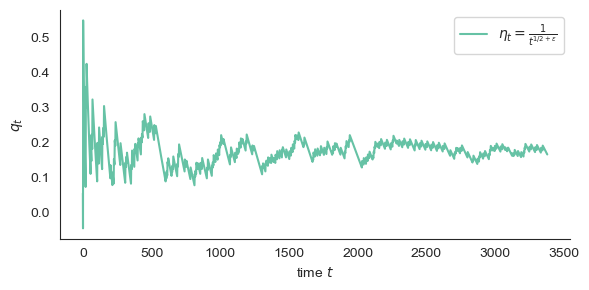

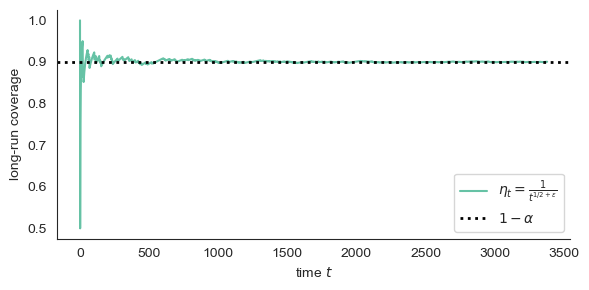

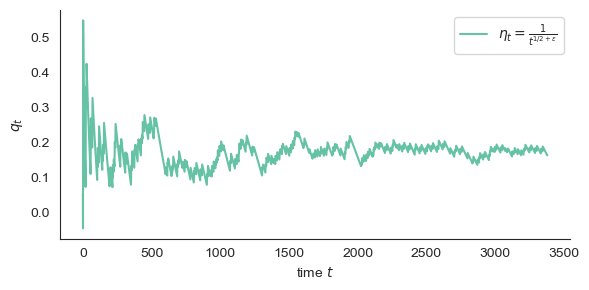

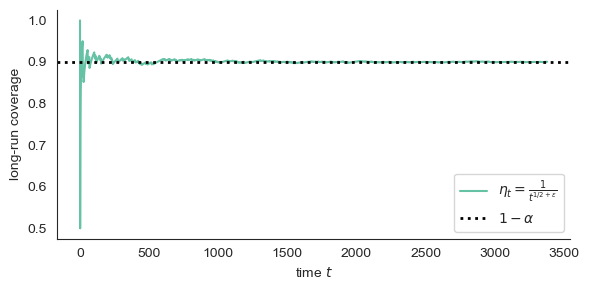

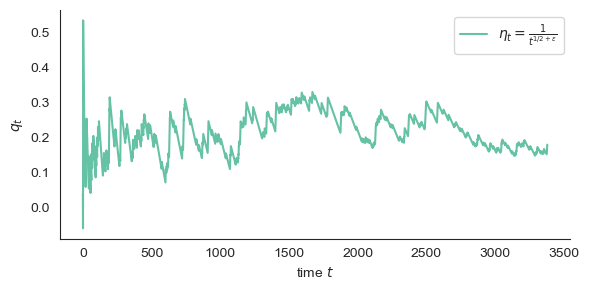

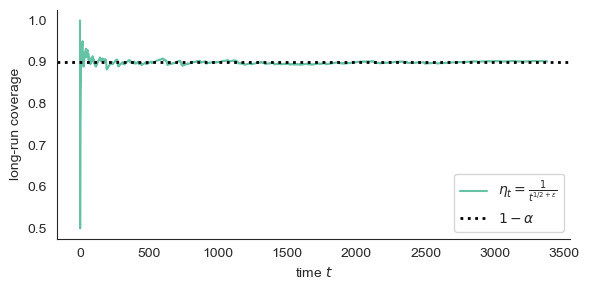

In [12]:
y_true_aligned = elec_y[100:]
# AR(2)
y_pred_ar2 = get_preds(elec_y, elec_lag[:, :2], tinit=100)
ar2_met = compute_coverage_metrics(y_true_aligned, y_pred_ar2, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(ar2_met, alpha=0.1, W=1000)
CI_ar2_decaying = ar2_met['q_decaying'] * 2
# AR(2) + covariate
X_ar2_cov = np.column_stack([elec_lag[:, :2], elec_x[:, 0]])
y_pred_ar2_cov = get_preds(elec_y, X_ar2_cov, tinit=100)
ar2_cov_met = compute_coverage_metrics(y_true_aligned, y_pred_ar2_cov, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(ar2_cov_met, alpha=0.1, W=1000)
CI_ar2_cov_decaying = ar2_cov_met['q_decaying'] * 2
# Only covariate
y_pred_cov = get_preds(elec_y, elec_x, tinit=100)
cov_met = compute_coverage_metrics(y_true_aligned, y_pred_cov, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(cov_met, alpha=0.1, W=1000)
CI_cov_decaying = cov_met['q_decaying'] * 2

In [13]:
print(f'mean coverage for covarite is:', np.mean(cov_met['observed_coverages_decaying']))
print(f'mean coverage for ar2+cov is:', np.mean(ar2_cov_met['observed_coverages_decaying']))
print(f'mean coverage for ar is:', np.mean(ar2_met['observed_coverages_decaying']))

mean coverage for covarite is: 0.900887573964497
mean coverage for ar2+cov is: 0.9005917159763314
mean coverage for ar is: 0.9005917159763314


# Super Learner 

Fold 0: train=565, val=563
Fold 1: train=1128, val=563
Fold 2: train=1691, val=563
Fold 3: train=2254, val=563
Fold 4: train=2817, val=563
Final meta-learner weights: [0.42205706 0.41112294 0.16682   ]


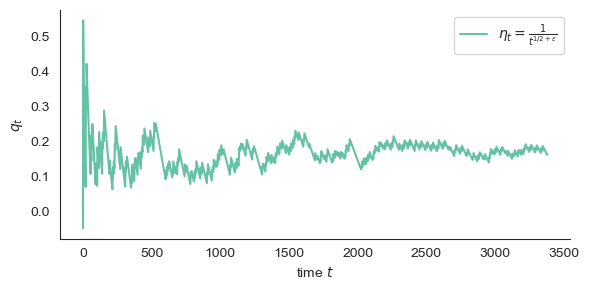

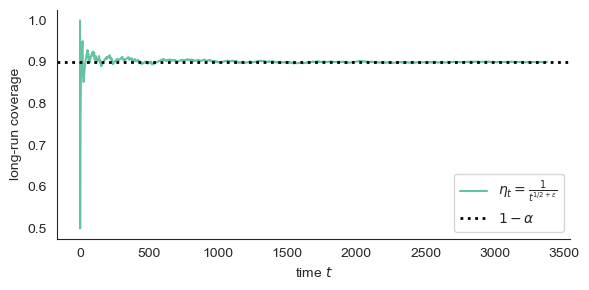

In [15]:
from sklearn.model_selection import TimeSeriesSplit
from scipy.optimize import minimize
import numpy as np

tinit = 100
y_true = elec_y[tinit:]

# --- Base learners (ELEC2 setup) ---
# NOTE: these functions should return predictions on any given subset of the data,
# not trained once on the whole dataset.
def base_preds(train_idx, val_idx):
    """Fit base learners on train_idx and predict on val_idx."""
    y_tr, X_tr_ar2 = elec_y[train_idx], elec_lag[train_idx, :2]
    _, X_va_ar2 = elec_y[val_idx], elec_lag[val_idx, :2]

    y_tr, X_tr_ar2cov = elec_y[train_idx], np.column_stack([elec_lag[train_idx, :2], elec_x[train_idx, 0]])
    _, X_va_ar2cov = elec_y[val_idx], np.column_stack([elec_lag[val_idx, :2], elec_x[val_idx, 0]])

    y_tr, X_tr_cov = elec_y[train_idx], elec_x[train_idx, :]
    _, X_va_cov = elec_y[val_idx], elec_x[val_idx, :]

    # Each get_preds should fit a model on (y_tr, X_tr_*) and return preds on X_va_*
    pred_ar2     = get_preds(elec_y, elec_lag[:, :2], tinit=tinit)[val_idx]
    pred_ar2_cov = get_preds(elec_y, np.column_stack([elec_lag[:, :2], elec_x[:, 0]]), tinit=tinit)[val_idx]
    pred_cov     = get_preds(elec_y, elec_x, tinit=tinit)[val_idx]

    return np.column_stack([pred_ar2, pred_ar2_cov, pred_cov])

# --- Cross-validation setup ---
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# --- Optimize convex weights ---
def optimize_weights(X, y, alpha1=0.0, alpha2=0.0):
    init_phi = np.ones(X.shape[1]) / X.shape[1]

    def mse_loss(phi):
        y_pred = X @ phi
        mse = np.mean((y - y_pred) ** 2)
        l1 = alpha1 * np.sum(np.abs(phi))
        l2 = alpha2 * np.sum(phi**2)
        return mse + l1 + l2

    constraints = [{'type': 'eq', 'fun': lambda phi: np.sum(phi) - 1}]
    bounds = [(0, 1)] * X.shape[1]
    result = minimize(mse_loss, init_phi, bounds=bounds, constraints=constraints)
    return result.x

# --- Collect OOF base learner predictions ---
meta_features = np.full((len(y_true), 3), np.nan)

for fold, (train_idx, val_idx) in enumerate(tscv.split(y_true)):
    print(f"Fold {fold}: train={len(train_idx)}, val={len(val_idx)}")

    # Get base learner OOF predictions for this fold
    preds_val = base_preds(train_idx, val_idx)
    meta_features[val_idx, :] = preds_val

# --- Drop any NaNs (first folds if insufficient history) ---
valid_rows = ~np.isnan(meta_features).any(axis=1)
X_meta_cv = meta_features[valid_rows]
y_meta_cv = y_true[valid_rows]

# --- Optimize weights globally using OOF base predictions ---
meta_weights = optimize_weights(X_meta_cv, y_meta_cv)
print("Final meta-learner weights:", meta_weights)

# --- Final Super Learner ---
# Refit base learners on full training data
y_pred_ar2     = get_preds(elec_y, elec_lag[:, :2], tinit=tinit)
y_pred_ar2_cov = get_preds(elec_y, np.column_stack([elec_lag[:, :2], elec_x[:, 0]]), tinit=tinit)
y_pred_cov     = get_preds(elec_y, elec_x, tinit=tinit)

X_meta_full = np.column_stack([y_pred_ar2, y_pred_ar2_cov, y_pred_cov])
super_preds = X_meta_full @ meta_weights

# --- Evaluate ---
super_met = compute_coverage_metrics(
    y_true, super_preds,
    alpha=0.1, epsilon=0.1, W=1000, C=1
)

plot_coverage_results(super_met, alpha=0.1, W=1000)
CI_sl_decaying = super_met['q_decaying'] * 2

In [16]:
print(f'mean coverage for Super Learner is:', np.mean(super_met['observed_coverages_decaying']))


mean coverage for Super Learner is: 0.9002958579881657


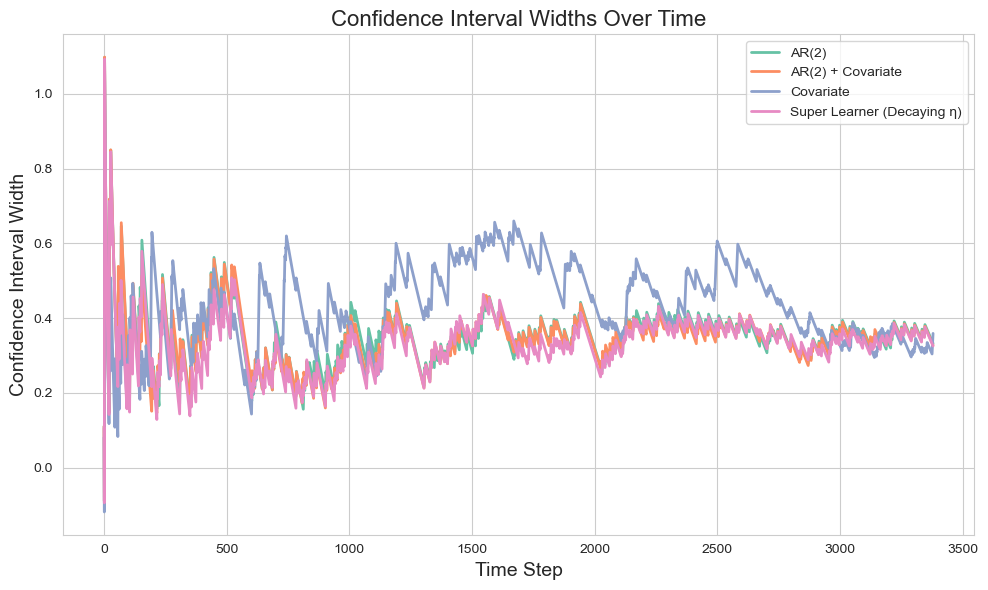

In [17]:
## line comparison plot 
## store important result to one file

import matplotlib.pyplot as plt

# Step 1: Generate a common index (e.g., time steps)
n = len(CI_cov_decaying)
x = list(range(n))  # n is the number of CI values

# Step 2: Plot setup
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Step 3: Plot each method's CI width as a line
plt.plot(x, CI_ar2_decaying[-n:], label='AR(2)', linewidth=2)
plt.plot(x, CI_ar2_cov_decaying[-n:], label='AR(2) + Covariate', linewidth=2)
plt.plot(x, CI_cov_decaying, label='Covariate', linewidth=2)
plt.plot(x, CI_sl_decaying[-n:], label='Super Learner (Decaying η)', linewidth=2)


# Step 4: Enhance plot readability
plt.title('Confidence Interval Widths Over Time', fontsize=16)
plt.xlabel('Time Step', fontsize=14)
plt.ylabel('Confidence Interval Width', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()


# COMA 

Mean deterministic coverage: 0.8973372781065089
Mean randomized coverage: 0.8970414201183432
Mean CI width — COMA (det): 0.3463302292971794
Mean CI width — COMA (rand): 0.34569130588042685
Mean CI width — Super Learner: 0.33263187376808057


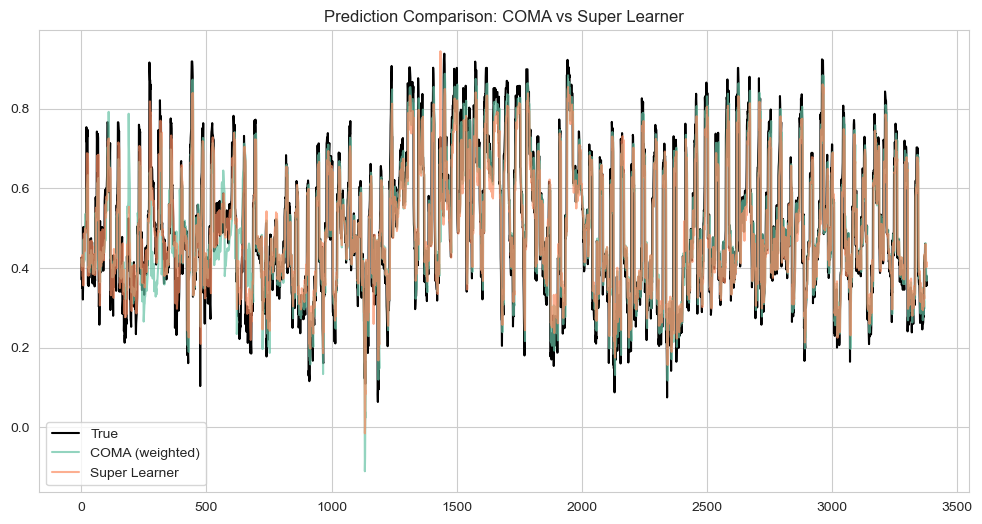

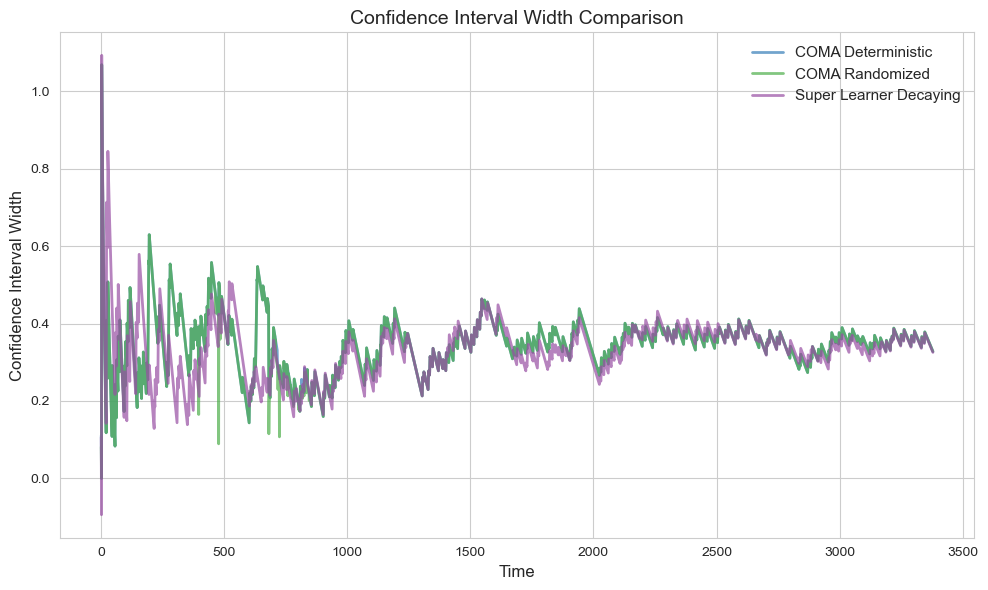

In [18]:
# --- Step 1: Minimum aligned length ---
min_len = min(
    len(ar2_met['q_decaying']),
    len(ar2_cov_met['q_decaying']),
    len(cov_met['q_decaying']),
    len(CI_sl_decaying),
    len(y_true)  # already aligned after tinit
)

# --- Step 2: CI half-widths (2 * q_decaying) for base learners ---
ci_matrix = np.column_stack([
    CI_ar2_decaying[-min_len:],       # AR(2)
    CI_ar2_cov_decaying[-min_len:],   # AR(2) + covariate
    CI_cov_decaying[-min_len:]        # Covariate only
])

# Hedge weights across experts (AdaHedge)
adahedAlg = adahedge(loss_matrix=ci_matrix)
weights_plain = adahedAlg["weights"]

# --- Step 3: Build prediction intervals for each base learner ---
intervals_ar2 = np.column_stack([
    y_pred_ar2[-min_len:] - ar2_met['q_decaying'][-min_len:],
    y_pred_ar2[-min_len:] + ar2_met['q_decaying'][-min_len:]
])

intervals_ar2_cov = np.column_stack([
    y_pred_ar2_cov[-min_len:] - ar2_cov_met['q_decaying'][-min_len:],
    y_pred_ar2_cov[-min_len:] + ar2_cov_met['q_decaying'][-min_len:]
])

intervals_cov = np.column_stack([
    y_pred_cov[-min_len:] - cov_met['q_decaying'][-min_len:],
    y_pred_cov[-min_len:] + cov_met['q_decaying'][-min_len:]
])

intervals_list_plain = [intervals_ar2, intervals_ar2_cov, intervals_cov]

# --- Step 4: Align test labels ---
y_test_aligned = y_true[-min_len:]

# --- Step 5: Run COMA ---
result_plain = coma_loop(intervals_list_plain, weights_plain, y_test_aligned)

print("Mean deterministic coverage:", result_plain["mean_m_cov"])
print("Mean randomized coverage:", result_plain["mean_wm_cov"])

# --- Step 6: Compute widths ---
pi_m   = result_plain["pi_m"]   # deterministic intervals
pi_wm  = result_plain["pi_wm"]  # randomized intervals

coma_width_det  = np.array([loss_fun(ci) for ci in pi_m])
coma_width_rand = np.array([loss_fun(ci) for ci in pi_wm])

CI_super_decaying = CI_sl_decaying[-min_len:]

print("Mean CI width — COMA (det):", np.nanmean(coma_width_det))
print("Mean CI width — COMA (rand):", np.nanmean(coma_width_rand))
print("Mean CI width — Super Learner:", np.mean(CI_super_decaying))

# --- Step 7: Compare predictions ---
base_preds_matrix = np.column_stack([
    y_pred_ar2[-min_len:], 
    y_pred_ar2_cov[-min_len:], 
    y_pred_cov[-min_len:]
])

# Case 1: weights_plain is shape (n, k)
coma_preds_weighted = np.sum(base_preds_matrix * weights_plain, axis=1)

plt.figure(figsize=(12, 6))
plt.plot(y_test_aligned, label="True", color="black")
plt.plot(coma_preds_weighted, label="COMA (weighted)", alpha=0.7)
plt.plot(super_preds[-min_len:], label="Super Learner", alpha=0.7)
plt.legend()
plt.title("Prediction Comparison: COMA vs Super Learner")
plt.show()

# --- Step 8: Plot CI widths ---
colors = sns.color_palette("Set1", 4)
plt.figure(figsize=(10, 6))
plt.plot(coma_width_det, label='COMA Deterministic', linewidth=2, alpha=0.7, color=colors[1])
plt.plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha=0.7, color=colors[2])
plt.plot(CI_super_decaying, label='Super Learner Decaying', linewidth=2, alpha=0.7, color=colors[3])

plt.xlabel('Time', fontsize=12)
plt.ylabel('Confidence Interval Width', fontsize=12)
plt.title('Confidence Interval Width Comparison', fontsize=14)
plt.legend(frameon=False, fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

# COMA+SL

Mean deterministic coverage(+SL): 0.8994082840236687
Mean randomized coverage(+SL): 0.899112426035503
Mean CI width — COMA (det): 0.3463302292971794
Mean CI width — COMA (rand): 0.34525126931696376
Mean CI width — COMA (det) + SL: 0.3327340188052694
Mean CI width — COMA (rand) + SL: 0.33264222981198155


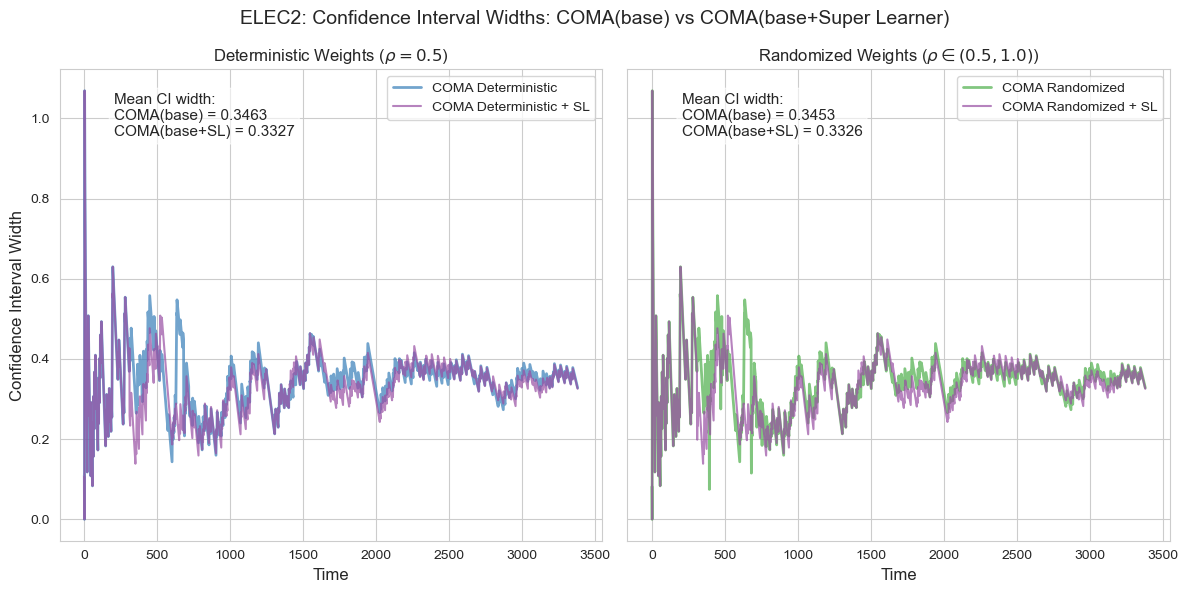

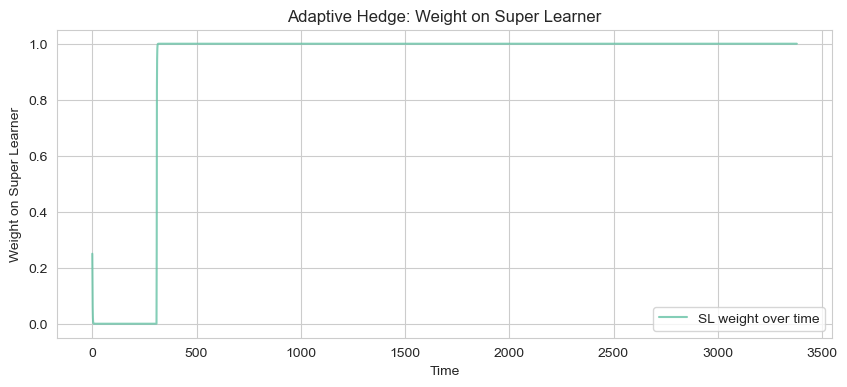

In [19]:

min_len = min(
    len(ar2_met['q_decaying']),
    len(ar2_cov_met['q_decaying']),
    len(cov_met['q_decaying']),
    len(super_met['q_decaying']),
    len(y_true)   # already aligned after tinit
)

CI_ar2_decaying      = 2 * ar2_met['q_decaying'][-min_len:]
CI_ar2_cov_decaying  = 2 * ar2_cov_met['q_decaying'][-min_len:]
CI_cov_decaying      = 2 * cov_met['q_decaying'][-min_len:]
CI_sl_decaying       = 2 * super_met['q_decaying'][-min_len:]

ci_matrix_sl = np.column_stack([
    CI_ar2_decaying,
    CI_ar2_cov_decaying,
    CI_cov_decaying,
    CI_sl_decaying
])
adahedAlg_sl = adahedge(loss_matrix=ci_matrix_sl)
weights_sl = adahedAlg_sl["weights"]

intervals_ar2 = np.column_stack([
    y_pred_ar2[-min_len:] - ar2_met['q_decaying'][-min_len:],
    y_pred_ar2[-min_len:] + ar2_met['q_decaying'][-min_len:]
])

intervals_ar2_cov = np.column_stack([
    y_pred_ar2_cov[-min_len:] - ar2_cov_met['q_decaying'][-min_len:],
    y_pred_ar2_cov[-min_len:] + ar2_cov_met['q_decaying'][-min_len:]
])

intervals_cov = np.column_stack([
    y_pred_cov[-min_len:] - cov_met['q_decaying'][-min_len:],
    y_pred_cov[-min_len:] + cov_met['q_decaying'][-min_len:]
])

intervals_sl = np.column_stack([
    super_preds[-min_len:] - super_met['q_decaying'][-min_len:],
    super_preds[-min_len:] + super_met['q_decaying'][-min_len:]
])


y_test_aligned = y_true[-min_len:]

intervals_list_base = [intervals_ar2, intervals_ar2_cov, intervals_cov]
result_base = coma_loop(intervals_list_base, weights_sl[:, :3], y_test_aligned)

pi_m_base  = result_base["pi_m"]
pi_wm_base = result_base["pi_wm"]

coma_width_det  = np.array([loss_fun(ci) for ci in pi_m_base])
coma_width_rand = np.array([loss_fun(ci) for ci in pi_wm_base])

intervals_list_sl = [intervals_ar2, intervals_ar2_cov, intervals_cov, intervals_sl]
result_sl = coma_loop(intervals_list_sl, weights_sl, y_test_aligned)
print("Mean deterministic coverage(+SL):", result_sl["mean_m_cov"])
print("Mean randomized coverage(+SL):", result_sl["mean_wm_cov"])
pi_m_sl  = result_sl["pi_m"]
pi_wm_sl = result_sl["pi_wm"]

coma_width_det_sl  = np.array([loss_fun(ci) for ci in pi_m_sl])
coma_width_rand_sl = np.array([loss_fun(ci) for ci in pi_wm_sl])

print("Mean CI width — COMA (det):", np.nanmean(coma_width_det))
print("Mean CI width — COMA (rand):", np.nanmean(coma_width_rand))
print("Mean CI width — COMA (det) + SL:", np.nanmean(coma_width_det_sl))
print("Mean CI width — COMA (rand) + SL:", np.nanmean(coma_width_rand_sl))

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

axes[0].plot(coma_width_det, label='COMA Deterministic', linewidth=2, alpha=0.7, color=colors[1])
axes[0].plot(coma_width_det_sl, label='COMA Deterministic + SL', linewidth=1.5, alpha=0.7, color=colors[3])
axes[0].set_title("Deterministic Weights ($\\rho=0.5$)", fontsize=12)
axes[0].set_xlabel("Time", fontsize=12)
axes[0].set_ylabel("Confidence Interval Width", fontsize=12)
axes[0].legend()

mean_det = np.nanmean(coma_width_det)
mean_det_sl = np.nanmean(coma_width_det_sl)
axes[0].text(0.1, 0.95,
             f"Mean CI width:\nCOMA(base) = {mean_det:.4f}\nCOMA(base+SL) = {mean_det_sl:.4f}",
             transform=axes[0].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

# Randomized subplot
axes[1].plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha=0.7, color=colors[2])
axes[1].plot(coma_width_rand_sl, label='COMA Randomized + SL', linewidth=1.5, alpha=0.7, color=colors[3])
axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
axes[1].set_xlabel("Time", fontsize=12)
axes[1].legend()

mean_rand = np.nanmean(coma_width_rand)
mean_rand_sl = np.nanmean(coma_width_rand_sl)
axes[1].text(0.1, 0.95,
             f"Mean CI width:\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
             transform=axes[1].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.suptitle("ELEC2: Confidence Interval Widths: COMA(base) vs COMA(base+Super Learner)", fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(weights_sl[:, -1], label="SL weight over time", alpha=0.8)
plt.xlabel("Time")
plt.ylabel("Weight on Super Learner")
plt.title("Adaptive Hedge: Weight on Super Learner")
plt.legend()
plt.show()

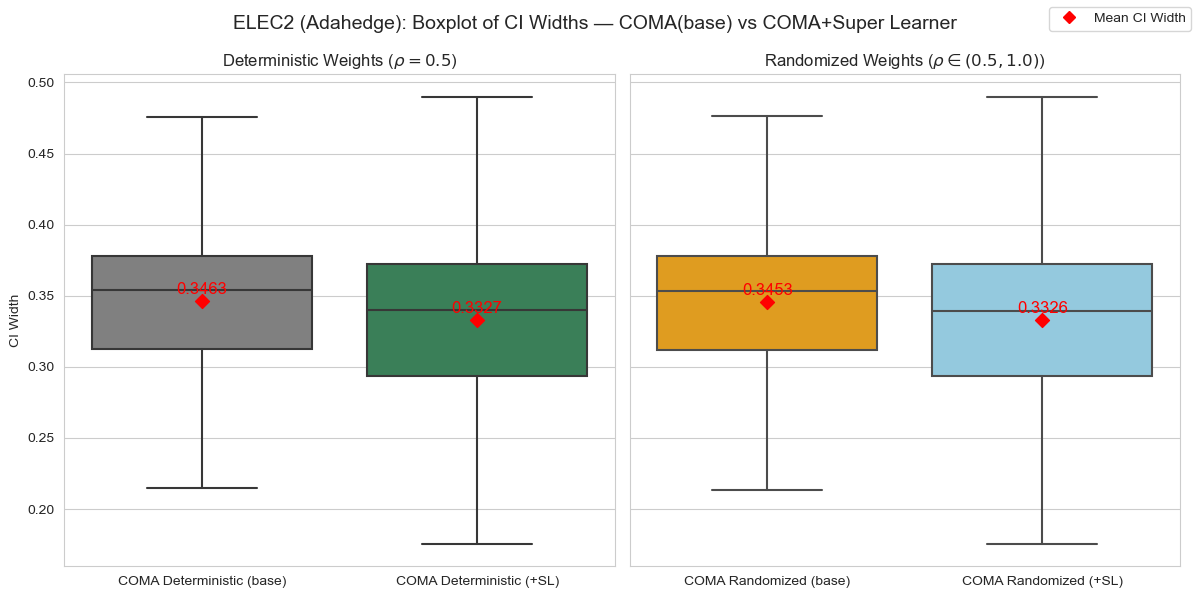

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Collect into dictionary
data_dict = {
    "COMA Deterministic (base)": coma_width_det,
    "COMA Deterministic (+SL)": coma_width_det_sl,
    "COMA Randomized (base)": coma_width_rand,
    "COMA Randomized (+SL)": coma_width_rand_sl
}

# Convert to DataFrame
df_box = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_dict.items()]))
df_long = df_box.melt(var_name="Method", value_name="CI Width")

# Split deterministic vs randomized
det_methods = ["COMA Deterministic (base)", "COMA Deterministic (+SL)"]
rand_methods = ["COMA Randomized (base)", "COMA Randomized (+SL)"]

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

palette = {"COMA Deterministic (base)": "gray",
           "COMA Deterministic (+SL)": "seagreen",
           "COMA Randomized (base)": "orange",
           "COMA Randomized (+SL)": "skyblue"}

# --- Deterministic subplot ---
sns.boxplot(x="Method", y="CI Width", data=df_long[df_long["Method"].isin(det_methods)],
            order=det_methods, palette=palette, showfliers=False, ax=axes[0])

means_det = [np.nanmean(data_dict[m]) for m in det_methods]
for i, m in enumerate(det_methods):
    axes[0].scatter(i, means_det[i], color="red", marker="D", s=50, zorder=3)
    axes[0].text(i, means_det[i]+0.005, f"{means_det[i]:.4f}", ha='center', fontsize=12, color="red")

axes[0].set_title("Deterministic Weights ($\\rho=0.5$)")
axes[0].set_xlabel("")
axes[0].set_ylabel("CI Width")

# --- Randomized subplot ---
sns.boxplot(x="Method", y="CI Width", data=df_long[df_long["Method"].isin(rand_methods)],
            order=rand_methods, palette=palette, showfliers=False, ax=axes[1])

means_rand = [np.nanmean(data_dict[m]) for m in rand_methods]
for i, m in enumerate(rand_methods):
    axes[1].scatter(i, means_rand[i], color="red", marker="D", s=50, zorder=3)
    axes[1].text(i, means_rand[i]+0.005, f"{means_rand[i]:.4f}", ha='center', fontsize=12, color="red")

axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

# Legend for red diamond
fig.legend(handles=[plt.Line2D([0],[0], color='red', marker='D', linestyle='', label='Mean CI Width')],
           loc='upper right')

plt.suptitle("ELEC2 (Adahedge): Boxplot of CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.show()

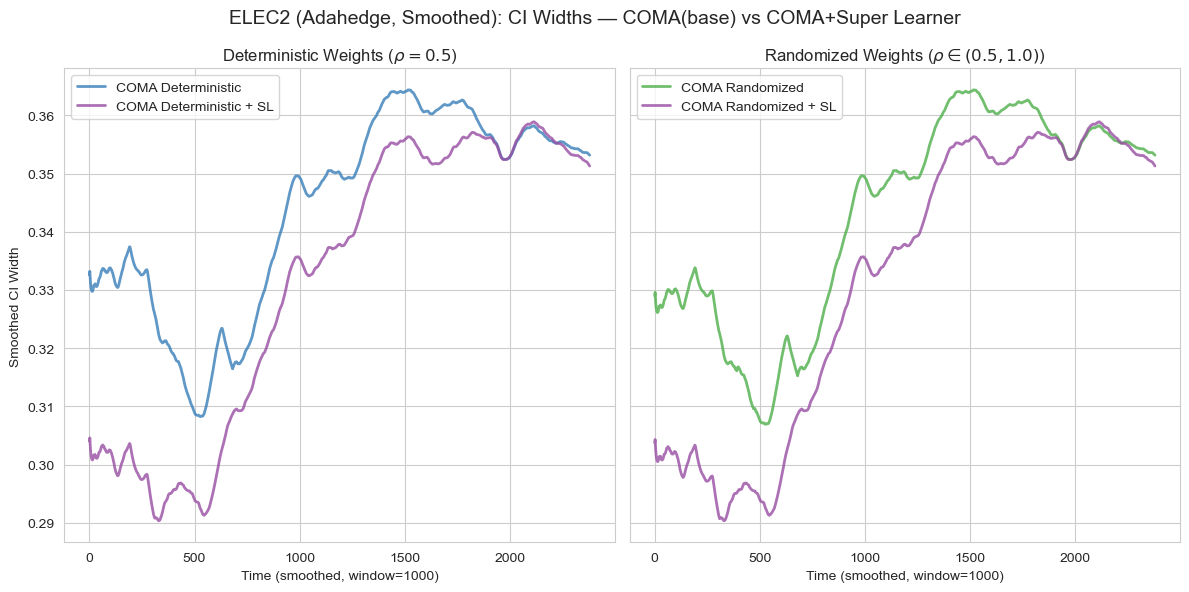

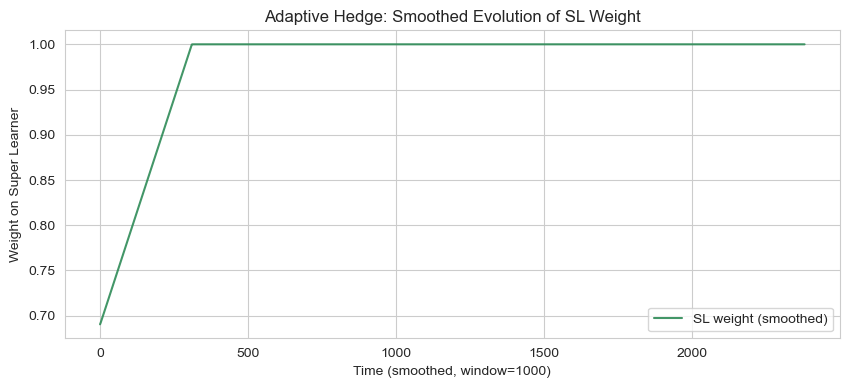

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Helper function for smoothing ---
def smooth_series(series, window=500):
    return np.convolve(series, np.ones(window)/window, mode='valid')

window = 1000  # smoothing window size

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# --- Deterministic subplot (smoothed) ---
axes[0].plot(smooth_series(coma_width_det, window), label='COMA Deterministic', linewidth=2, alpha=0.8, color=colors[1])
axes[0].plot(smooth_series(coma_width_det_sl, window), label='COMA Deterministic + SL', linewidth=2, alpha=0.8, color=colors[3])
axes[0].set_title("Deterministic Weights ($\\rho=0.5$)", fontsize=12)
axes[0].set_xlabel("Time (smoothed, window=1000)")
axes[0].set_ylabel("Smoothed CI Width")
axes[0].legend()

# --- Randomized subplot (smoothed) ---
axes[1].plot(smooth_series(coma_width_rand, window), label='COMA Randomized', linewidth=2, alpha=0.8, color=colors[2])
axes[1].plot(smooth_series(coma_width_rand_sl, window), label='COMA Randomized + SL', linewidth=2, alpha=0.8, color=colors[3])
axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
axes[1].set_xlabel("Time (smoothed, window=1000)")
axes[1].legend()

plt.suptitle("ELEC2 (Adahedge, Smoothed): CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.show()

# --- Smooth SL weight plot ---
plt.figure(figsize=(10,4))
plt.plot(smooth_series(weights_sl[:, -1], window), label="SL weight (smoothed)", alpha=0.9, color="seagreen")
plt.xlabel("Time (smoothed, window=1000)")
plt.ylabel("Weight on Super Learner")
plt.title("Adaptive Hedge: Smoothed Evolution of SL Weight")
plt.legend()
plt.show()

## Hedge 

Mean deterministic coverage (COMA base): 0.8976331360946745
Mean randomized coverage (COMA base): 0.8872781065088757
Mean deterministic coverage (COMA+SL): 0.8994082840236687
Mean randomized coverage (COMA+SL): 0.8914201183431952
Mean CI width — COMA(base, det): 0.34698819880613635
Mean CI width — COMA(base, rand): 0.3286013479407168
Mean CI width — COMA(base+SL, det): 0.33420858923855334
Mean CI width — COMA(base+SL, rand): 0.32350906430108906


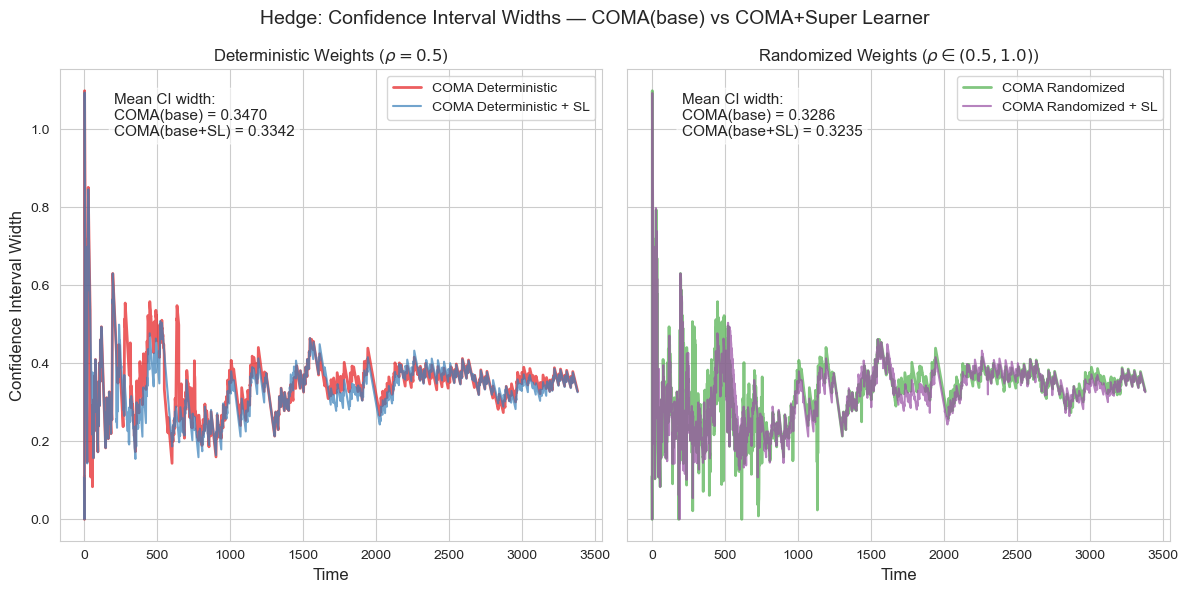

In [ ]:
# --- Step 1: Run Hedge separately for base (3 experts) and base+SL (4 experts) ---
hedAlg_base = hedge(ci_matrix, eta=0.1)        # shape (N,3)
hedAlg_sl   = hedge(ci_matrix_sl, eta=0.1)     # shape (N,4)

weights_base = hedAlg_base["weights"]
weights_sl   = hedAlg_sl["weights"]

N_base, K_base = weights_base.shape
N_sl, K_sl     = weights_sl.shape

# Ensure test labels align correctly with the shorter horizon
min_len = min(len(y_true), N_base, N_sl)
y_test_aligned = y_true[-min_len:]

pi_m_base, pi_wm_base = [], []
pi_m_sl, pi_wm_sl     = [], []

m_cov_base = np.full(min_len, np.nan)
wm_cov_base = np.full(min_len, np.nan)
m_cov_sl   = np.full(min_len, np.nan)
wm_cov_sl  = np.full(min_len, np.nan)

# --- Step 3: Loop over time (like R's for(i in 1:N)) ---
for i in range(min_len):
    # --- Base (3 experts) ---
    conf_base = np.vstack([intervals_list_base[j][i] for j in range(len(intervals_list_base))])
    maj_int_base  = majority_vote(conf_base, w=weights_base[i], rho=0.5)
    wmaj_int_base = majority_vote(conf_base, w=weights_base[i], rho=np.random.uniform(0.5, 1.0))

    pi_m_base.append(maj_int_base)
    pi_wm_base.append(wmaj_int_base)
    m_cov_base[i]  = covr_fun(maj_int_base, y_test_aligned[i])
    wm_cov_base[i] = covr_fun(wmaj_int_base, y_test_aligned[i])

    # --- Base+SL (4 experts) ---
    conf_sl = np.vstack([intervals_list_sl[j][i] for j in range(len(intervals_list_sl))])
    maj_int_sl  = majority_vote(conf_sl, w=weights_sl[i], rho=0.5)
    wmaj_int_sl = majority_vote(conf_sl, w=weights_sl[i], rho=np.random.uniform(0.5, 1.0))

    pi_m_sl.append(maj_int_sl)
    pi_wm_sl.append(wmaj_int_sl)
    m_cov_sl[i]  = covr_fun(maj_int_sl, y_test_aligned[i])
    wm_cov_sl[i] = covr_fun(wmaj_int_sl, y_test_aligned[i])


# --- Step 4: Compute widths ---
coma_width_det     = np.array([loss_fun(ci) for ci in pi_m_base])
coma_width_rand    = np.array([loss_fun(ci) for ci in pi_wm_base])
coma_width_det_sl  = np.array([loss_fun(ci) for ci in pi_m_sl])
coma_width_rand_sl = np.array([loss_fun(ci) for ci in pi_wm_sl])

# --- Step 5: Summaries ---
print("Mean deterministic coverage (COMA base):", np.nanmean(m_cov_base))
print("Mean randomized coverage (COMA base):", np.nanmean(wm_cov_base))
print("Mean deterministic coverage (COMA+SL):", np.nanmean(m_cov_sl))
print("Mean randomized coverage (COMA+SL):", np.nanmean(wm_cov_sl))

print("Mean CI width — COMA(base, det):", np.nanmean(coma_width_det))
print("Mean CI width — COMA(base, rand):", np.nanmean(coma_width_rand))
print("Mean CI width — COMA(base+SL, det):", np.nanmean(coma_width_det_sl))
print("Mean CI width — COMA(base+SL, rand):", np.nanmean(coma_width_rand_sl))

# --- Step 7: Subplot comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# --- Deterministic subplot ---
axes[0].plot(coma_width_det, label='COMA Deterministic', linewidth=2, alpha=0.7, color=colors[0])
axes[0].plot(coma_width_det_sl, label='COMA Deterministic + SL', linewidth=1.5, alpha=0.7, color=colors[1])
axes[0].set_title("Deterministic Weights ($\\rho=0.5$)", fontsize=12)
axes[0].set_xlabel("Time", fontsize=12)
axes[0].set_ylabel("Confidence Interval Width", fontsize=12)
axes[0].legend()

# Annotate means
mean_det = np.nanmean(coma_width_det)
mean_det_sl = np.nanmean(coma_width_det_sl)
axes[0].text(0.1, 0.95,
             f"Mean CI width:\nCOMA(base) = {mean_det:.4f}\nCOMA(base+SL) = {mean_det_sl:.4f}",
             transform=axes[0].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

# --- Randomized subplot ---
axes[1].plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha=0.7, color=colors[2])
axes[1].plot(coma_width_rand_sl, label='COMA Randomized + SL', linewidth=1.5, alpha=0.7, color=colors[3])
axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
axes[1].set_xlabel("Time", fontsize=12)
axes[1].legend()

# Annotate means
mean_rand = np.nanmean(coma_width_rand)
mean_rand_sl = np.nanmean(coma_width_rand_sl)
axes[1].text(0.1, 0.95,
             f"Mean CI width:\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
             transform=axes[1].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.suptitle("Hedge: Confidence Interval Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.show()

Mean CI width — COMA(base, det): 0.34313127178946035
Mean CI width — COMA(base, rand): 0.3311159618852349
Mean CI width — COMA(base+SL, det): 0.3310812774078587
Mean CI width — COMA(base+SL, rand): 0.32679658846843335


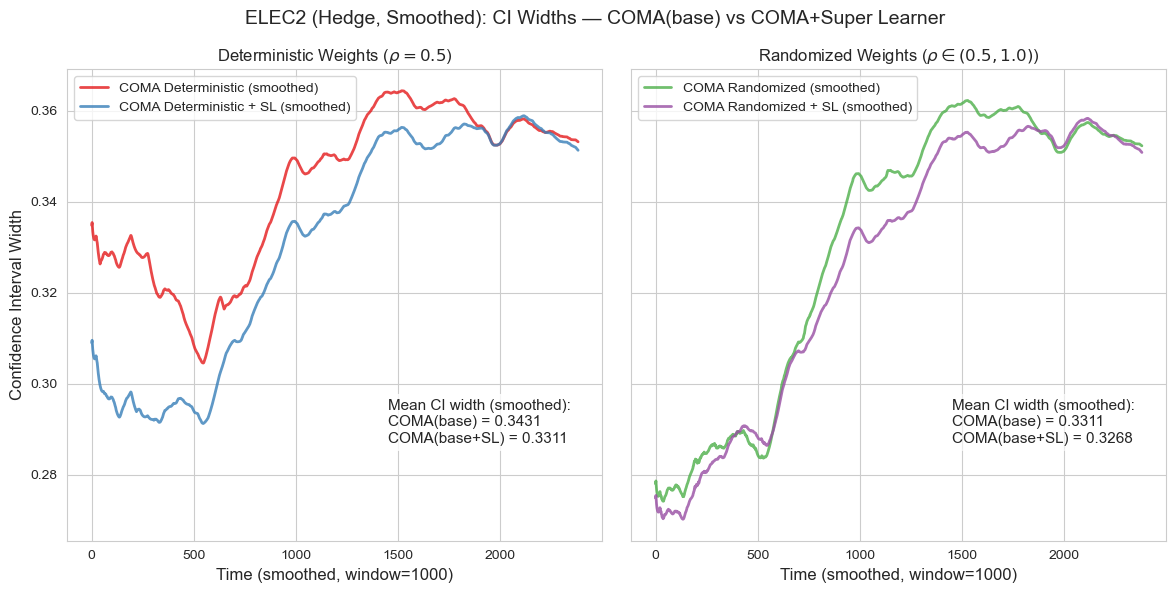

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Step 4 (already computed): widths ---
coma_width_det     = np.array([loss_fun(ci) for ci in pi_m_base])
coma_width_rand    = np.array([loss_fun(ci) for ci in pi_wm_base])
coma_width_det_sl  = np.array([loss_fun(ci) for ci in pi_m_sl])
coma_width_rand_sl = np.array([loss_fun(ci) for ci in pi_wm_sl])

# --- Step 4.1: Smooth with moving average ---
def smooth_series(series, window=500):
    """Apply rolling mean smoothing with specified window size."""
    return np.convolve(series, np.ones(window)/window, mode='valid')

coma_width_det_smooth     = smooth_series(coma_width_det, window=1000)
coma_width_rand_smooth    = smooth_series(coma_width_rand, window=1000)
coma_width_det_sl_smooth  = smooth_series(coma_width_det_sl, window=1000)
coma_width_rand_sl_smooth = smooth_series(coma_width_rand_sl, window=1000)

# --- Step 5: Summaries (on smoothed series) ---
print("Mean CI width — COMA(base, det):", np.nanmean(coma_width_det_smooth))
print("Mean CI width — COMA(base, rand):", np.nanmean(coma_width_rand_smooth))
print("Mean CI width — COMA(base+SL, det):", np.nanmean(coma_width_det_sl_smooth))
print("Mean CI width — COMA(base+SL, rand):", np.nanmean(coma_width_rand_sl_smooth))

# --- Step 6: Subplot comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# --- Deterministic subplot ---
axes[0].plot(coma_width_det_smooth, label='COMA Deterministic (smoothed)', linewidth=2, alpha=0.8, color=colors[0])
axes[0].plot(coma_width_det_sl_smooth, label='COMA Deterministic + SL (smoothed)', linewidth=2, alpha=0.8, color=colors[1])
axes[0].set_title("Deterministic Weights ($\\rho=0.5$)", fontsize=12)
axes[0].set_xlabel("Time (smoothed, window=1000)", fontsize=12)
axes[0].set_ylabel("Confidence Interval Width", fontsize=12)
axes[0].legend()

# Annotate means
mean_det = np.nanmean(coma_width_det_smooth)
mean_det_sl = np.nanmean(coma_width_det_sl_smooth)
axes[0].text(0.6, 0.3,
             f"Mean CI width (smoothed):\nCOMA(base) = {mean_det:.4f}\nCOMA(base+SL) = {mean_det_sl:.4f}",
             transform=axes[0].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# --- Randomized subplot ---
axes[1].plot(coma_width_rand_smooth, label='COMA Randomized (smoothed)', linewidth=2, alpha=0.8, color=colors[2])
axes[1].plot(coma_width_rand_sl_smooth, label='COMA Randomized + SL (smoothed)', linewidth=2, alpha=0.8, color=colors[3])
axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
axes[1].set_xlabel("Time (smoothed, window=1000)", fontsize=12)
axes[1].legend()

# Annotate means
mean_rand = np.nanmean(coma_width_rand_smooth)
mean_rand_sl = np.nanmean(coma_width_rand_sl_smooth)
axes[1].text(0.6, 0.3,
             f"Mean CI width (smoothed):\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
             transform=axes[1].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.suptitle("ELEC2 (Hedge, Smoothed): CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.show()